In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import pairwise_distances_argmin_min
import random

# Configuración visual para los gráficos
plt.style.use('ggplot')

Generando 3 centroides aleatorios...


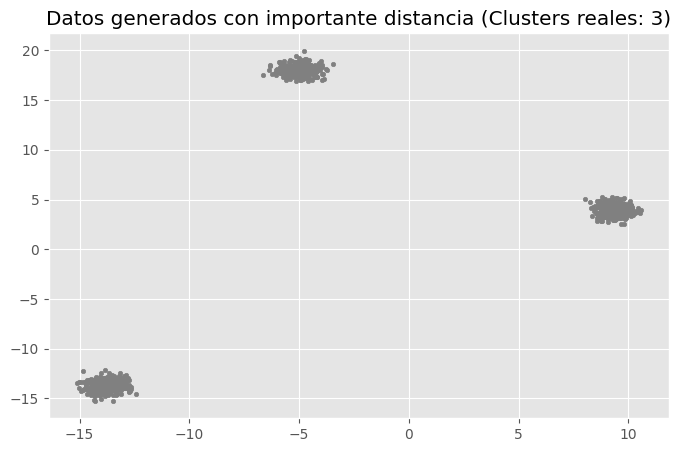

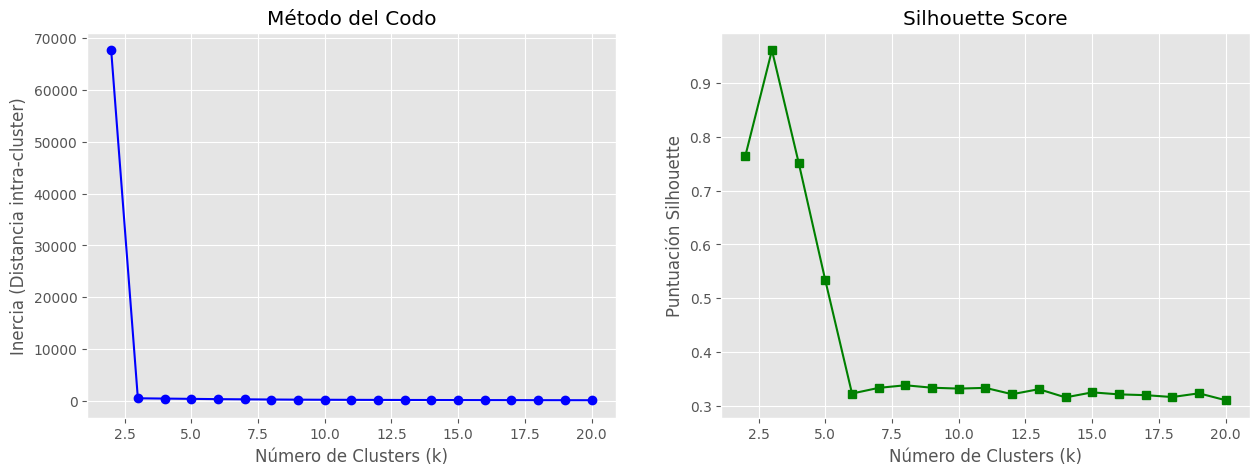

El modelo sugiere agrupar en k = 3 clusters.


In [2]:
# PUNTO 1: GENERADOR ALEATORIO Y EVALUACIÓN

# 1. Generar clusters aleatorios entre 1 y 20
num_centroides = random.randint(2, 20) # Usamos mínimo 2 para que el Silhouette Score funcione
print(f"Generando {num_centroides} centroides aleatorios...")

# Usamos center_box grande y cluster_std bajo para asegurar una "importante distancia" entre ellos
X_aleatorio, _ = make_blobs(n_samples=1000, centers=num_centroides, n_features=2,
                            cluster_std=0.5, center_box=(-20.0, 20.0), random_state=42)

# 2. Visualización inicial de los datos generados
plt.figure(figsize=(8, 5))
plt.scatter(X_aleatorio[:, 0], X_aleatorio[:, 1], s=10, color='gray')
plt.title(f"Datos generados con importante distancia (Clusters reales: {num_centroides})")
plt.show()

# 3. Aplicar Método del Codo y Silhouette Score
inercia = []
valores_silhouette = []
rango_k = range(2, 21) # Probamos de 2 a 20 clusters

for k in rango_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo_kmeans.fit_predict(X_aleatorio)

    inercia.append(modelo_kmeans.inertia_)
    valores_silhouette.append(silhouette_score(X_aleatorio, etiquetas))

# 4. Gráficas de demostración de efectividad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica del Codo
ax1.plot(rango_k, inercia, marker='o', color='blue')
ax1.set_title("Método del Codo")
ax1.set_xlabel("Número de Clusters (k)")
ax1.set_ylabel("Inercia (Distancia intra-cluster)")

# Gráfica de Silhouette
ax2.plot(rango_k, valores_silhouette, marker='s', color='green')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Número de Clusters (k)")
ax2.set_ylabel("Puntuación Silhouette")

plt.show()

# El valor máximo en la gráfica de Silhouette nos indica el "k" óptimo encontrado por el algoritmo
k_optimo = rango_k[np.argmax(valores_silhouette)]
print(f"El modelo sugiere agrupar en k = {k_optimo} clusters.")

In [5]:
# PUNTO 2: APRENDIZAJE SEMISUPERVISADO Y ACTIVO

from sklearn.metrics import pairwise_distances_argmin_min, silhouette_samples
import numpy as np

k_clusters = 50
print(f"Entrenando modelo con k={k_clusters} (sobre-agrupamiento inicial)...")

kmeans_real = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
etiquetas_asignadas = kmeans_real.fit_predict(X_imagenes)

print("\n--- 1. Aplicando Aprendizaje Semisupervisado ---")
indices_centroides, _ = pairwise_distances_argmin_min(kmeans_real.cluster_centers_, X_imagenes)

print(f"Se encontraron {k_clusters} imágenes representativas (índices):")
print(indices_centroides)
print(f"Lógica Semisupervisada: El experto humano revisa SOLAMENTE estas {k_clusters} imágenes y les pone etiqueta.")
print(f"Automáticamente, el modelo propaga esas {k_clusters} etiquetas a las {m_ejemplos} imágenes restantes.")


print("\n--- 2. Aplicando Aprendizaje Activo ---")
scores_individuales = silhouette_samples(X_imagenes, etiquetas_asignadas)

puntos_inciertos = np.argsort(scores_individuales)[:5]

print("El modelo solicita ayuda (Aprendizaje Activo).")
print("Por favor, etiqueta manualmente estas imágenes que son confusas y están en la frontera de los clusters:")
for idx in puntos_inciertos:
    print(f"- Imagen índice {idx} (Score de confianza: {scores_individuales[idx]:.4f})")

Entrenando modelo con k=50 (sobre-agrupamiento inicial)...

--- 1. Aplicando Aprendizaje Semisupervisado ---
Se encontraron 50 imágenes representativas (índices):
[10547 11509  5729 11102  1464  4852  8911 14792 11303  6437  6274 11959
  1775 12172 12770  4605  6445  7874  8167  3714  3347  6557  7313 10323
 14003  1631 11369 12373  9416  9169 11473 10469  4174  7568 11812  5797
  5279  5578   747 13036 13264  5783  8046  8212   153  9281 13553  2363
   638  1632]
Lógica Semisupervisada: El experto humano revisa SOLAMENTE estas 50 imágenes y les pone etiqueta.
Automáticamente, el modelo propaga esas 50 etiquetas a las 15000 imágenes restantes.

--- 2. Aplicando Aprendizaje Activo ---
El modelo solicita ayuda (Aprendizaje Activo).
Por favor, etiqueta manualmente estas imágenes que son confusas y están en la frontera de los clusters:
- Imagen índice 5624 (Score de confianza: -0.1988)
- Imagen índice 6771 (Score de confianza: -0.1970)
- Imagen índice 1492 (Score de confianza: -0.1958)
- I

MOSTRANDO GRAFICAMENTE LAS 5 IMAGENES QUE EL MODELO NO PUDO CLASIFICAR BIEN:


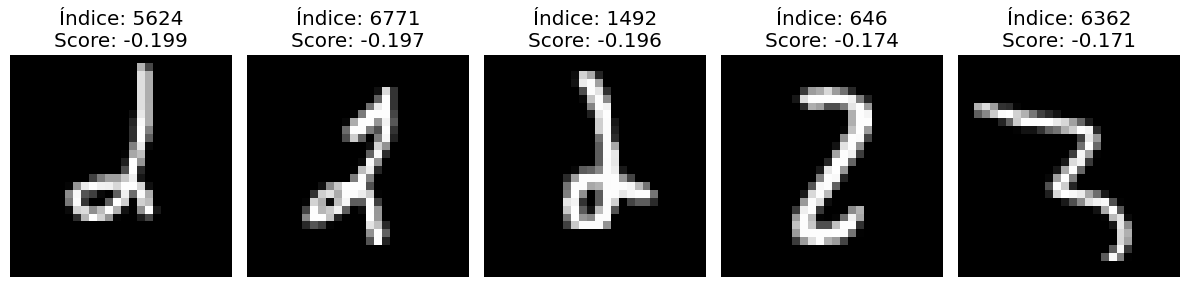

In [7]:
import matplotlib.pyplot as plt

# EXTRA: VISUALIZACIÓN DE APRENDIZAJE ACTIVO

print("MOSTRANDO GRAFICAMENTE LAS 5 IMAGENES QUE EL MODELO NO PUDO CLASIFICAR BIEN:")

plt.figure(figsize=(12, 3))
for i, idx in enumerate(puntos_inciertos):
    # Recuperamos la imagen original de 28x28 (deshaciendo el aplanamiento)
    imagen_confusa = X_imagenes[idx].reshape(28, 28)

    plt.subplot(1, 5, i + 1)
    plt.imshow(imagen_confusa, cmap='gray')
    plt.title(f"Índice: {idx}\nScore: {scores_individuales[idx]:.3f}")
    plt.axis('off')

plt.tight_layout()
plt.show()